# CLEANING FOR CLUSTER IMPROVEMENT 

- Start with 014_data_with_time_bins parquet file
- End with 015_data_severity_max_0_to_3 parquet file

OBJECTIVES: 
- collapse severity 3+4 = 3 FATAL
- precipitation winsorize at 99th percentile
- wind gusts winsorize at 99th percentile
- weather days since last rainfall winsorize at 99th percentile

In [34]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

import seaborn as sns

from kmodes.kprototypes import KPrototypes
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score, silhouette_samples, adjusted_rand_score
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from scipy import stats

In [35]:
df = pd.read_parquet(
    r"C:\Users\lucyq\Dropbox\AMDP\THESIS\014_data_with_time_bins.parquet").copy()
print('Number of accidents: ', df.shape[0],
      '\nNumber of variables:', df.shape[1])

Number of accidents:  14849 
Number of variables: 36


In [36]:
df['max_injury_severity'].value_counts()

max_injury_severity
1    12182
0     1902
2      449
4      168
3      148
Name: count, dtype: int64

In [37]:
# ADJUSTMENT OF MAX_SEVERITY TO IMPROVE CATEGORY BALANCE:
# Collapse the rare death categories 3 and 4 together (both fatal)
df['severity_max'] = df['max_injury_severity'].copy()
df.loc[df['severity_max'].isin([3, 4]), 'severity_max'] = 3

# Check distribution
print(df['severity_max'].value_counts().sort_index())

severity_max
0     1902
1    12182
2      449
3      316
Name: count, dtype: int64


In [38]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14849 entries, 0 to 14848
Data columns (total 37 columns):
 #   Column                        Non-Null Count  Dtype                      
---  ------                        --------------  -----                      
 0   Protocollo                    14849 non-null  int64                      
 1   total_injury_severity         14849 non-null  int32                      
 2   max_injury_severity           14849 non-null  int32                      
 3   num_pedestrians_hit           14849 non-null  int64                      
 4   num_male                      14849 non-null  int32                      
 5   num_female                    14849 non-null  int32                      
 6   num_unknown_gender            14849 non-null  int32                      
 7   multiple_pedestrians          14849 non-null  int32                      
 8   severity_winsorized           14849 non-null  int32                      
 9   DataOraIncidente 

In [39]:
df.isnull().sum().sum()

0

In [40]:
def plot_transformation_diagnostic(original, transformed,
                                   original_name='Original',
                                   transformed_name='Transformed',
                                   bins=50, figsize=(12, 10)):
    """
    Create diagnostic plots comparing original and transformed features.

    Parameters:
    -----------
    original : array-like
        Original feature values
    transformed : array-like
        Transformed feature values
    original_name : str, optional
        Label for original data (default: 'Original')
    transformed_name : str, optional
        Label for transformed data (default: 'Transformed')
    bins : int, optional
        Number of bins for histograms (default: 50)
    figsize : tuple, optional
        Figure size (default: (12, 10))

    Returns:
    --------
    fig, axes : matplotlib figure and axes objects
    """
    fig, axes = plt.subplots(2, 2, figsize=figsize)

    # Original distribution
    axes[0, 0].hist(original, bins=bins, edgecolor='black', alpha=0.7)
    axes[0, 0].set_title(f'{original_name} Distribution')
    axes[0, 0].set_xlabel('Value')
    axes[0, 0].set_ylabel('Frequency')
    axes[0, 0].grid(alpha=0.3)

    # Transformed distribution
    axes[0, 1].hist(transformed, bins=bins, edgecolor='black',
                    color='orange', alpha=0.7)
    axes[0, 1].set_title(f'{transformed_name} Distribution')
    axes[0, 1].set_xlabel('Value')
    axes[0, 1].set_ylabel('Frequency')
    axes[0, 1].grid(alpha=0.3)

    # Boxplot comparison
    axes[1, 0].boxplot([original, transformed],
                       tick_labels=[original_name, transformed_name])
    axes[1, 0].set_title('Boxplot Comparison')
    axes[1, 0].set_ylabel('Value')
    axes[1, 0].grid(alpha=0.3)

    # Before/after scatter (showing what changed)
    axes[1, 1].scatter(original, transformed, alpha=0.5, s=20)

    # Add diagonal reference line
    min_val = min(original.min(), transformed.min())
    max_val = max(original.max(), transformed.max())
    axes[1, 1].plot([min_val, max_val], [min_val, max_val],
                    'r--', label='No change line', linewidth=2)

    axes[1, 1].set_xlabel(original_name)
    axes[1, 1].set_ylabel(transformed_name)
    axes[1, 1].set_title('Transformation Effect')
    axes[1, 1].legend()
    axes[1, 1].grid(alpha=0.3)

    plt.tight_layout()

    return fig, axes

WINSORISE PRECIPITATION

In [41]:
upper_limit = df['precipitation (mm)'].quantile(0.99)
df['precipitation_winsorized'] = df['precipitation (mm)'].clip(
    upper=upper_limit)

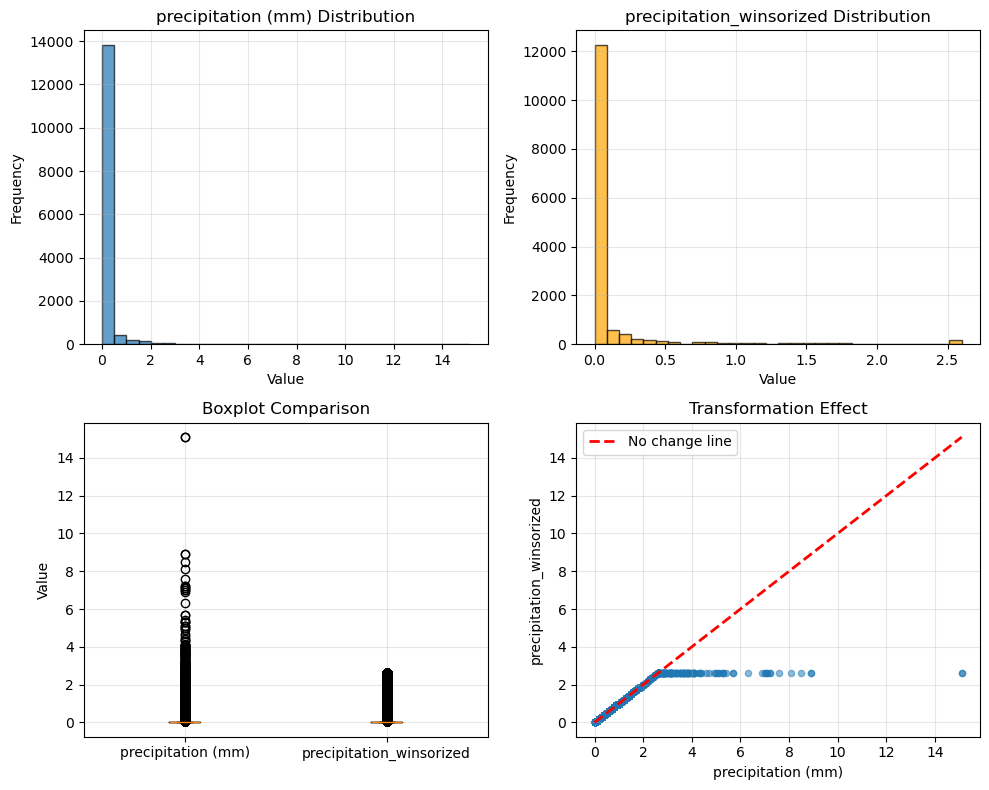

In [42]:
# View difference between original feature & winsorized feature
fig, axes = plot_transformation_diagnostic(
    df['precipitation (mm)'],
    df['precipitation_winsorized'],
    original_name='precipitation (mm)',
    transformed_name='precipitation_winsorized',
    bins=30,
    figsize=(10, 8)
)
plt.show()

WINSORIZE WEATHER DAYS 

In [43]:
upper_limit2 = df['weather_days_since_last_rain'].quantile(0.99)
df['dry_spells_winsorized'] = df['weather_days_since_last_rain'].clip(
    upper=upper_limit2)

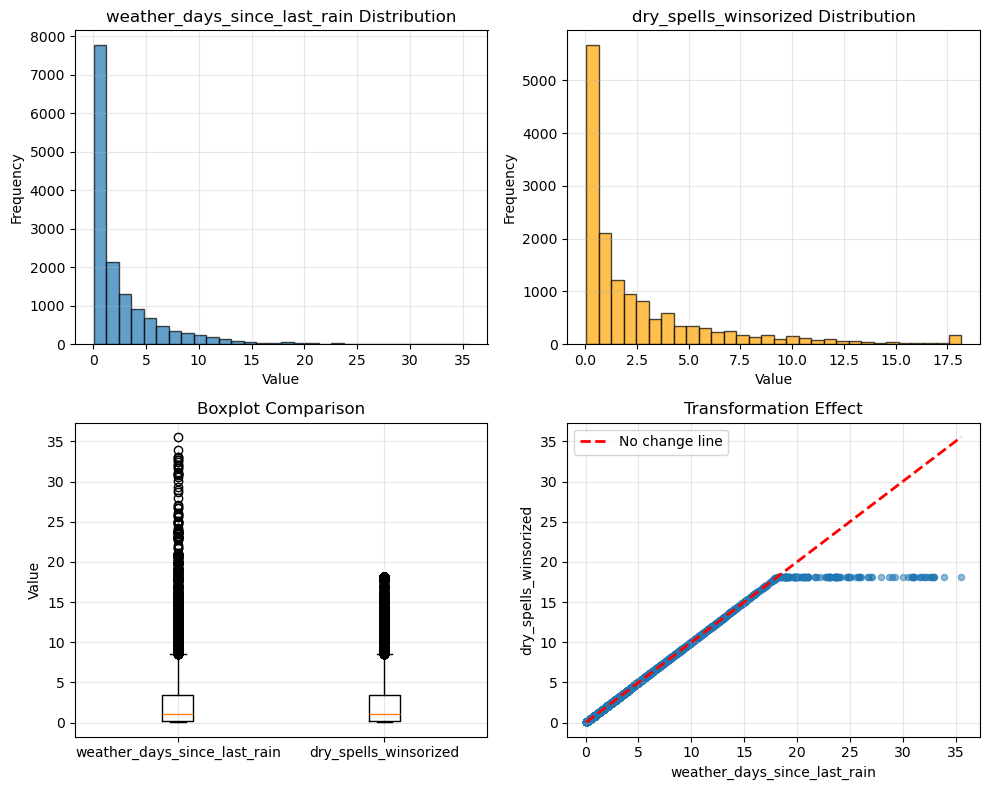

In [44]:
# View difference between original feature & winsorized feature
fig, axes = plot_transformation_diagnostic(
    df['weather_days_since_last_rain'],
    df['dry_spells_winsorized'],
    original_name='weather_days_since_last_rain',
    transformed_name='dry_spells_winsorized',
    bins=30,
    figsize=(10, 8)
)
plt.show()

WINSORIZE WIND GUSTS 

In [45]:
upper_limit3 = df['wind_gusts_10m (km/h)'].quantile(0.99)
df['wind_gusts_winsorized'] = df['wind_gusts_10m (km/h)'].clip(
    upper=upper_limit3)

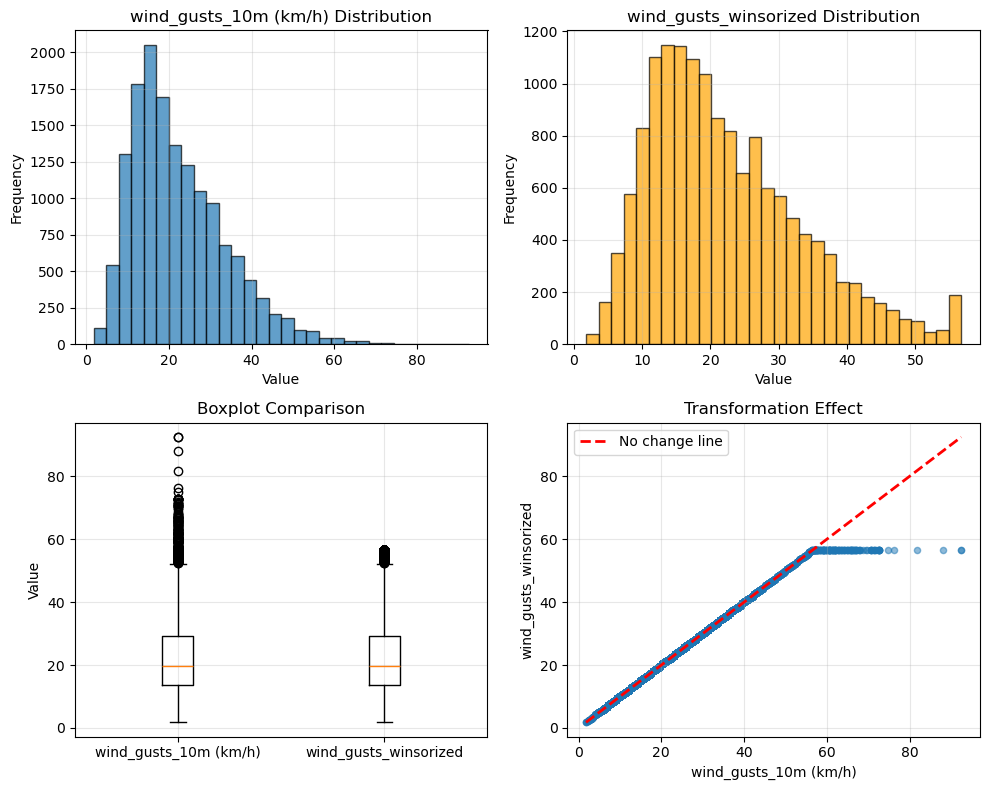

In [46]:
# View difference between original feature & winsorized feature
fig, axes = plot_transformation_diagnostic(
    df['wind_gusts_10m (km/h)'],
    df['wind_gusts_winsorized'],
    original_name='wind_gusts_10m (km/h)',
    transformed_name='wind_gusts_winsorized',
    bins=30,
    figsize=(10, 8)
)
plt.show()

In [47]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14849 entries, 0 to 14848
Data columns (total 40 columns):
 #   Column                        Non-Null Count  Dtype                      
---  ------                        --------------  -----                      
 0   Protocollo                    14849 non-null  int64                      
 1   total_injury_severity         14849 non-null  int32                      
 2   max_injury_severity           14849 non-null  int32                      
 3   num_pedestrians_hit           14849 non-null  int64                      
 4   num_male                      14849 non-null  int32                      
 5   num_female                    14849 non-null  int32                      
 6   num_unknown_gender            14849 non-null  int32                      
 7   multiple_pedestrians          14849 non-null  int32                      
 8   severity_winsorized           14849 non-null  int32                      
 9   DataOraIncidente 

In [48]:
df.to_parquet('015_data_severity_max_0_to_3.parquet', index=False)

In [ ]:
def plot_numerical_distributions(df, numerical_features):
    """
    Create comprehensive distribution plots for numerical features.
    Shows histogram with KDE and boxplot for each variable.
    """
    n_features = len(numerical_features)
    fig, axes = plt.subplots(n_features, 2, figsize=(14, 4*n_features))

    # Handle case of single feature
    if n_features == 1:
        axes = axes.reshape(1, -1)

    for idx, feature in enumerate(numerical_features):
        # Remove any NaN values for plotting
        data = df[feature].dropna()

        # Histogram with KDE
        axes[idx, 0].hist(data, bins=50, edgecolor='black', alpha=0.7)
        axes[idx, 0].set_xlabel(feature)
        axes[idx, 0].set_ylabel('Frequency')
        axes[idx, 0].set_title(f'{feature} - Distribution')

        # Add KDE on secondary axis
        ax2 = axes[idx, 0].twinx()
        data.plot.kde(ax=ax2, color='red', linewidth=2)
        ax2.set_ylabel('Density', color='red')
        ax2.tick_params(axis='y', labelcolor='red')

        # Boxplot
        axes[idx, 1].boxplot(data, vert=True)
        axes[idx, 1].set_ylabel(feature)
        axes[idx, 1].set_title(f'{feature} - Boxplot')
        axes[idx, 1].grid(axis='y', alpha=0.3)

        # Add statistics as text
        stats_text = f'Mean: {data.mean():.2f}\nMedian: {data.median():.2f}\nStd: {data.std():.2f}\nSkew: {data.skew():.2f}'
        axes[idx, 1].text(1.15, 0.5, stats_text, transform=axes[idx, 1].transAxes,
                          verticalalignment='center', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

    plt.tight_layout()
    plt.show()

    # Print summary statistics
    print("\n" + "="*60)
    print("SUMMARY STATISTICS")
    print("="*60)
    for feature in numerical_features:
        data = df[feature].dropna()
        print(f"\n{feature}:")
        print(f"  Min: {data.min():.2f}")
        print(f"  Q1:  {data.quantile(0.25):.2f}")
        print(f"  Median: {data.median():.2f}")
        print(f"  Q3:  {data.quantile(0.75):.2f}")
        print(f"  Max: {data.max():.2f}")
        print(f"  Skewness: {data.skew():.2f}")
        print(f"  Kurtosis: {data.kurtosis():.2f}")

In [ ]:
# Usage:
plot_numerical_distributions(df_clustering, numerical_for_clustering)